In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
data_path = Path('data/cholecseg8k/preprocessed_ssg')
from autoencoder.model_qwen import QwenAutoencoder
from PIL import Image
import random

In [ ]:
video, seq = 26, 2175

seg_path = data_path / f'video{video:02}' / f'video{video:02}_{seq:05}'
ae_path = seg_path / 'autoencoder' / 'best_ckpt.pth'

ae = QwenAutoencoder(
    input_dim=3584,
    latent_dim=3,
).to("cuda")
ae.load_state_dict(torch.load(ae_path, map_location="cuda"))
ae.eval()
pass

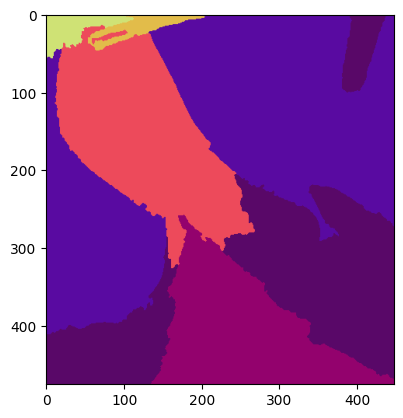

In [14]:
video, seq = 26, 2175
seg_path = data_path / f'video{video:02}' / f'video{video:02}_{seq:05}'
frame = 0
patch_lf_path_f = seg_path / 'qwen_instance_features_dim3' / f'frame_{frame:06}_f.npy'
patch_lf_path_s = seg_path / 'qwen_instance_features_dim3' / f'frame_{frame:06}_s.npy'
img_path = seg_path / 'images' / f'frame_{frame:06}.jpg'

patch_lf_f = np.load(patch_lf_path_f)
patch_lf_s = np.load(patch_lf_path_s)[0]
patch_lf = patch_lf_f[patch_lf_s]
color_transform = lambda c: c/2+0.5
plt.imshow(color_transform(patch_lf))
plt.show()

In [10]:
frame = 45

seg_path = data_path / f'video{video:02}' / f'video{video:02}_{seq:05}'
patch_lf_path_f = seg_path / 'qwen_instance_features' / f'frame_{frame:06}_f.npy'
patch_lf_path_s = seg_path / 'qwen_instance_features' / f'frame_{frame:06}_s.npy'
img_path = seg_path / 'images' / f'frame_{frame:06}.jpg'

patch_lf_f = np.load(patch_lf_path_f)
patch_lf_s = np.load(patch_lf_path_s)[0]

with torch.no_grad():
    patch_lf_f = ae.encode(torch.as_tensor(patch_lf_f, device='cuda', dtype=torch.float32)).detach().cpu().numpy()

img = Image.open(img_path)
patch_lf = patch_lf_f[patch_lf_s]

In [4]:
color_transform = lambda c: c/2+0.5

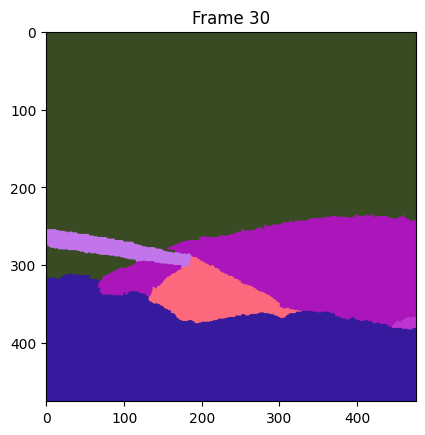

In [9]:
plt.imshow(color_transform(patch_lf)); plt.title(f'Frame {frame}'); plt.show()

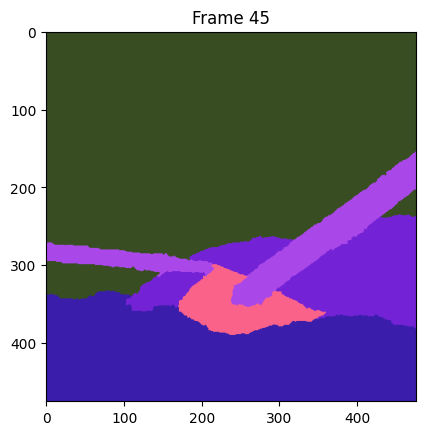

In [11]:
plt.imshow(color_transform(patch_lf)); plt.title(f'Frame {frame}'); plt.show()

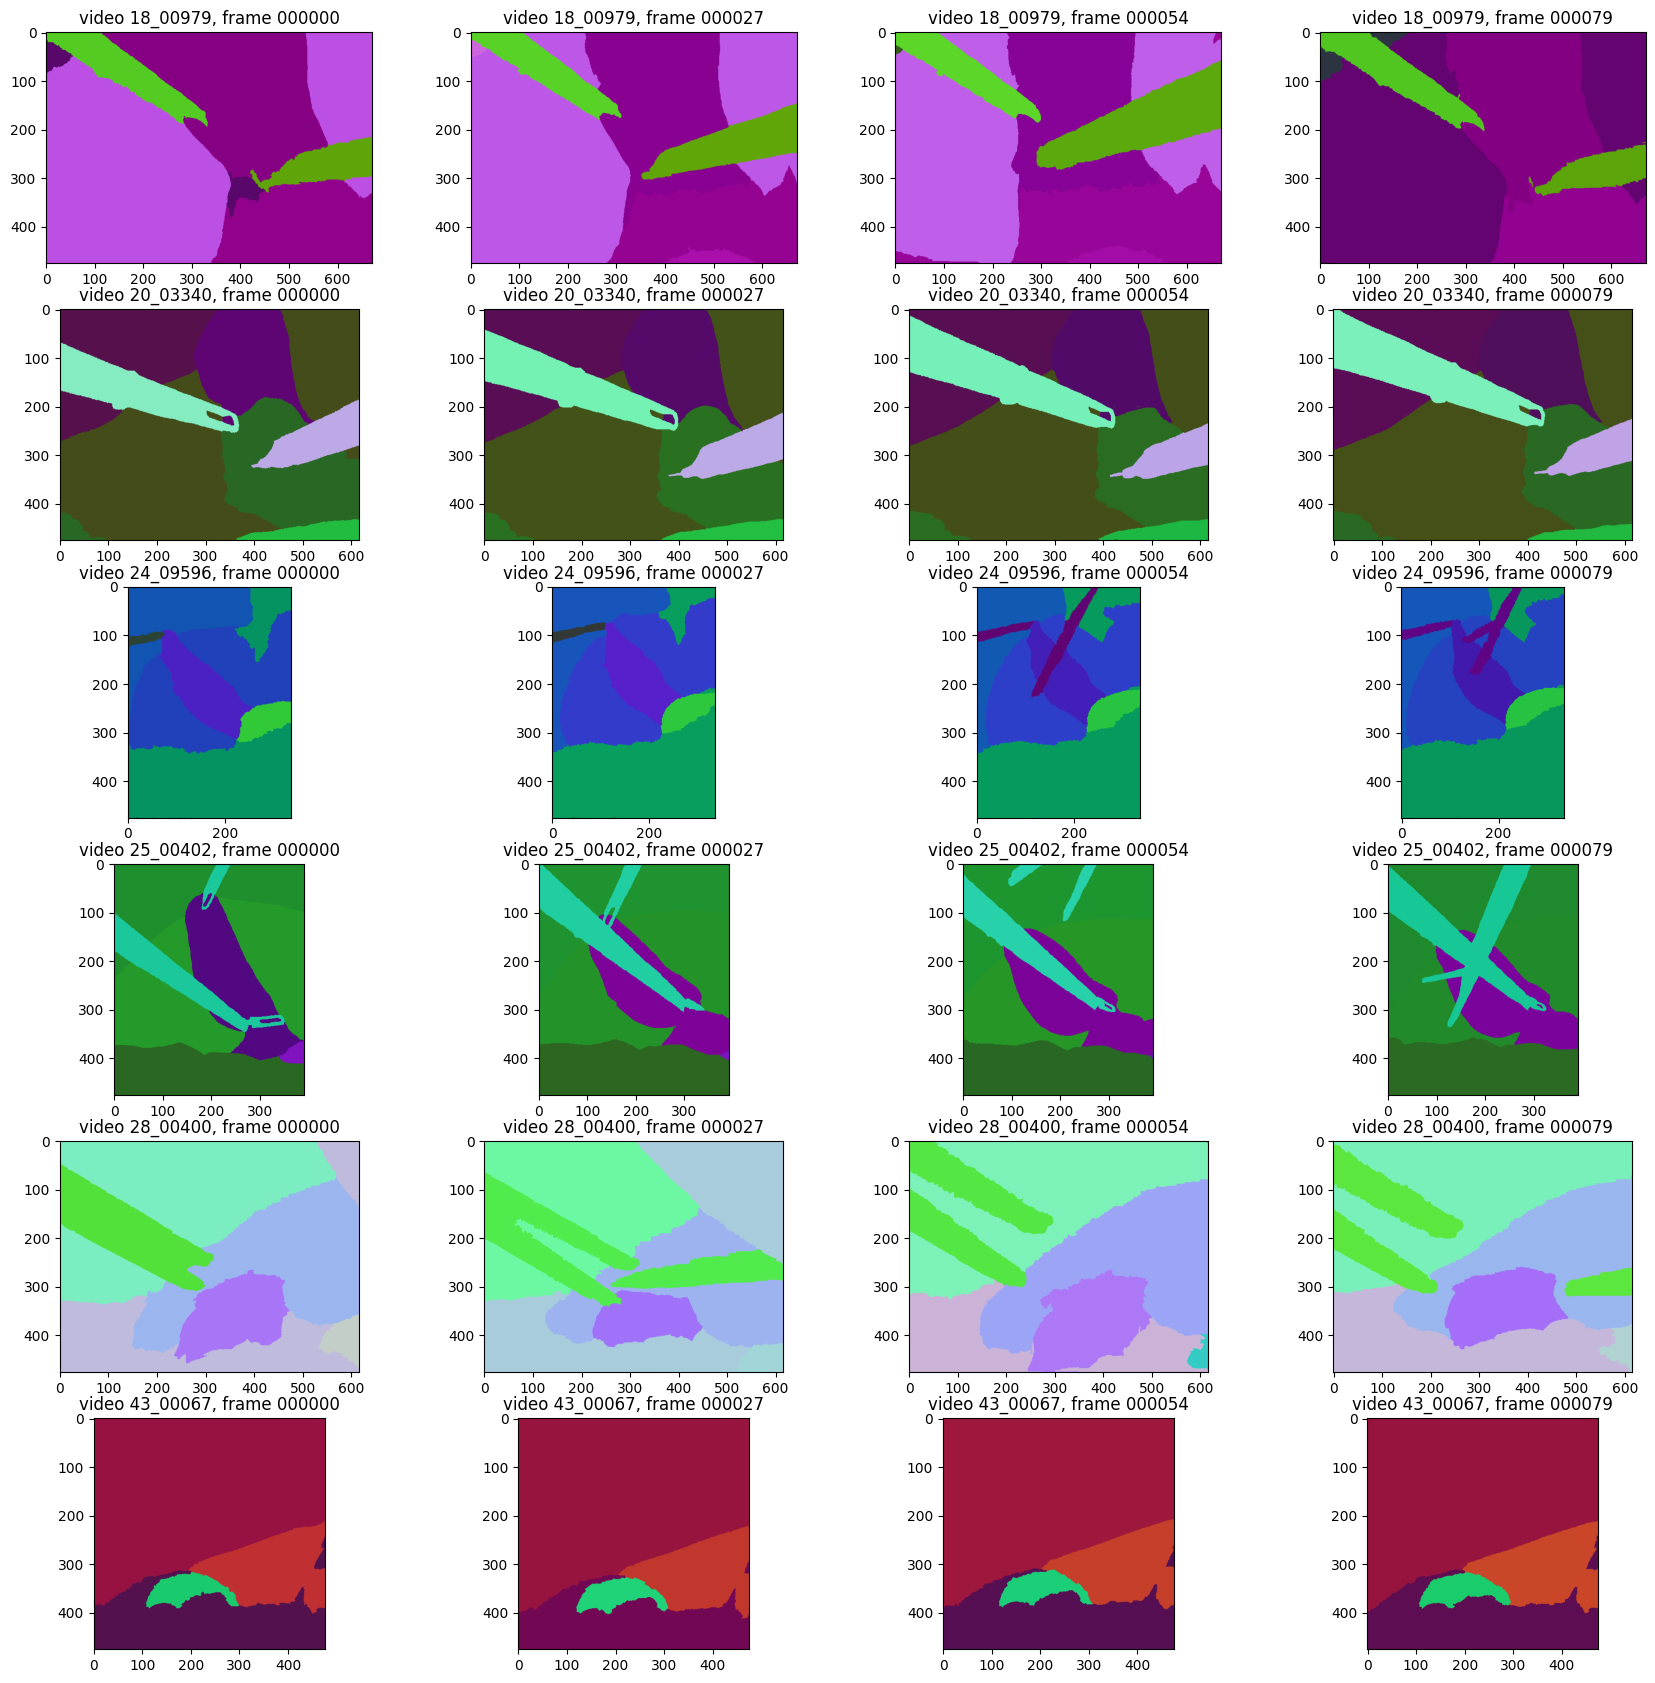

In [15]:
n_videos = 6
display_frames = [0, 27, 54, 79]

video_paths = list(data_path.iterdir())
vid_paths = sorted(random.sample(video_paths, n_videos))
seg_paths = [random.choice(list(vid_path.iterdir())) for vid_path in vid_paths]

fig, axs = plt.subplots(n_videos, len(display_frames), figsize=(21, 21))

for i, seg_path in enumerate(seg_paths):
    vid_id, seg_id = int(str(seg_path)[-8:-6]), int(str(seg_path)[-5:])

    ae_path = seg_path / 'autoencoder' / 'best_ckpt.pth'
    ae = QwenAutoencoder(
        input_dim=3584,
        latent_dim=3,
    ).to("cuda")
    ae.load_state_dict(torch.load(ae_path, map_location="cuda"))
    ae.eval()

    for j, frame_id in enumerate(display_frames):
        frame_path_f =  seg_path / 'qwen_instance_features' / f'frame_{frame_id:06}_f.npy'
        frame_path_s =  seg_path / 'qwen_instance_features' / f'frame_{frame_id:06}_s.npy'

        patch_lf_f = np.load(frame_path_f)
        patch_lf_s = np.load(frame_path_s)[0]

        with torch.no_grad():
            patch_lf_f = ae.encode(torch.as_tensor(patch_lf_f, device='cuda', dtype=torch.float32)).detach().cpu().numpy()
        patch_lf = patch_lf_f[patch_lf_s]
        axs[i, j].imshow(color_transform(patch_lf))
        axs[i, j].set_title(f'video {vid_id:02}_{seg_id:05}, frame {frame_id:06}')
plt.show()

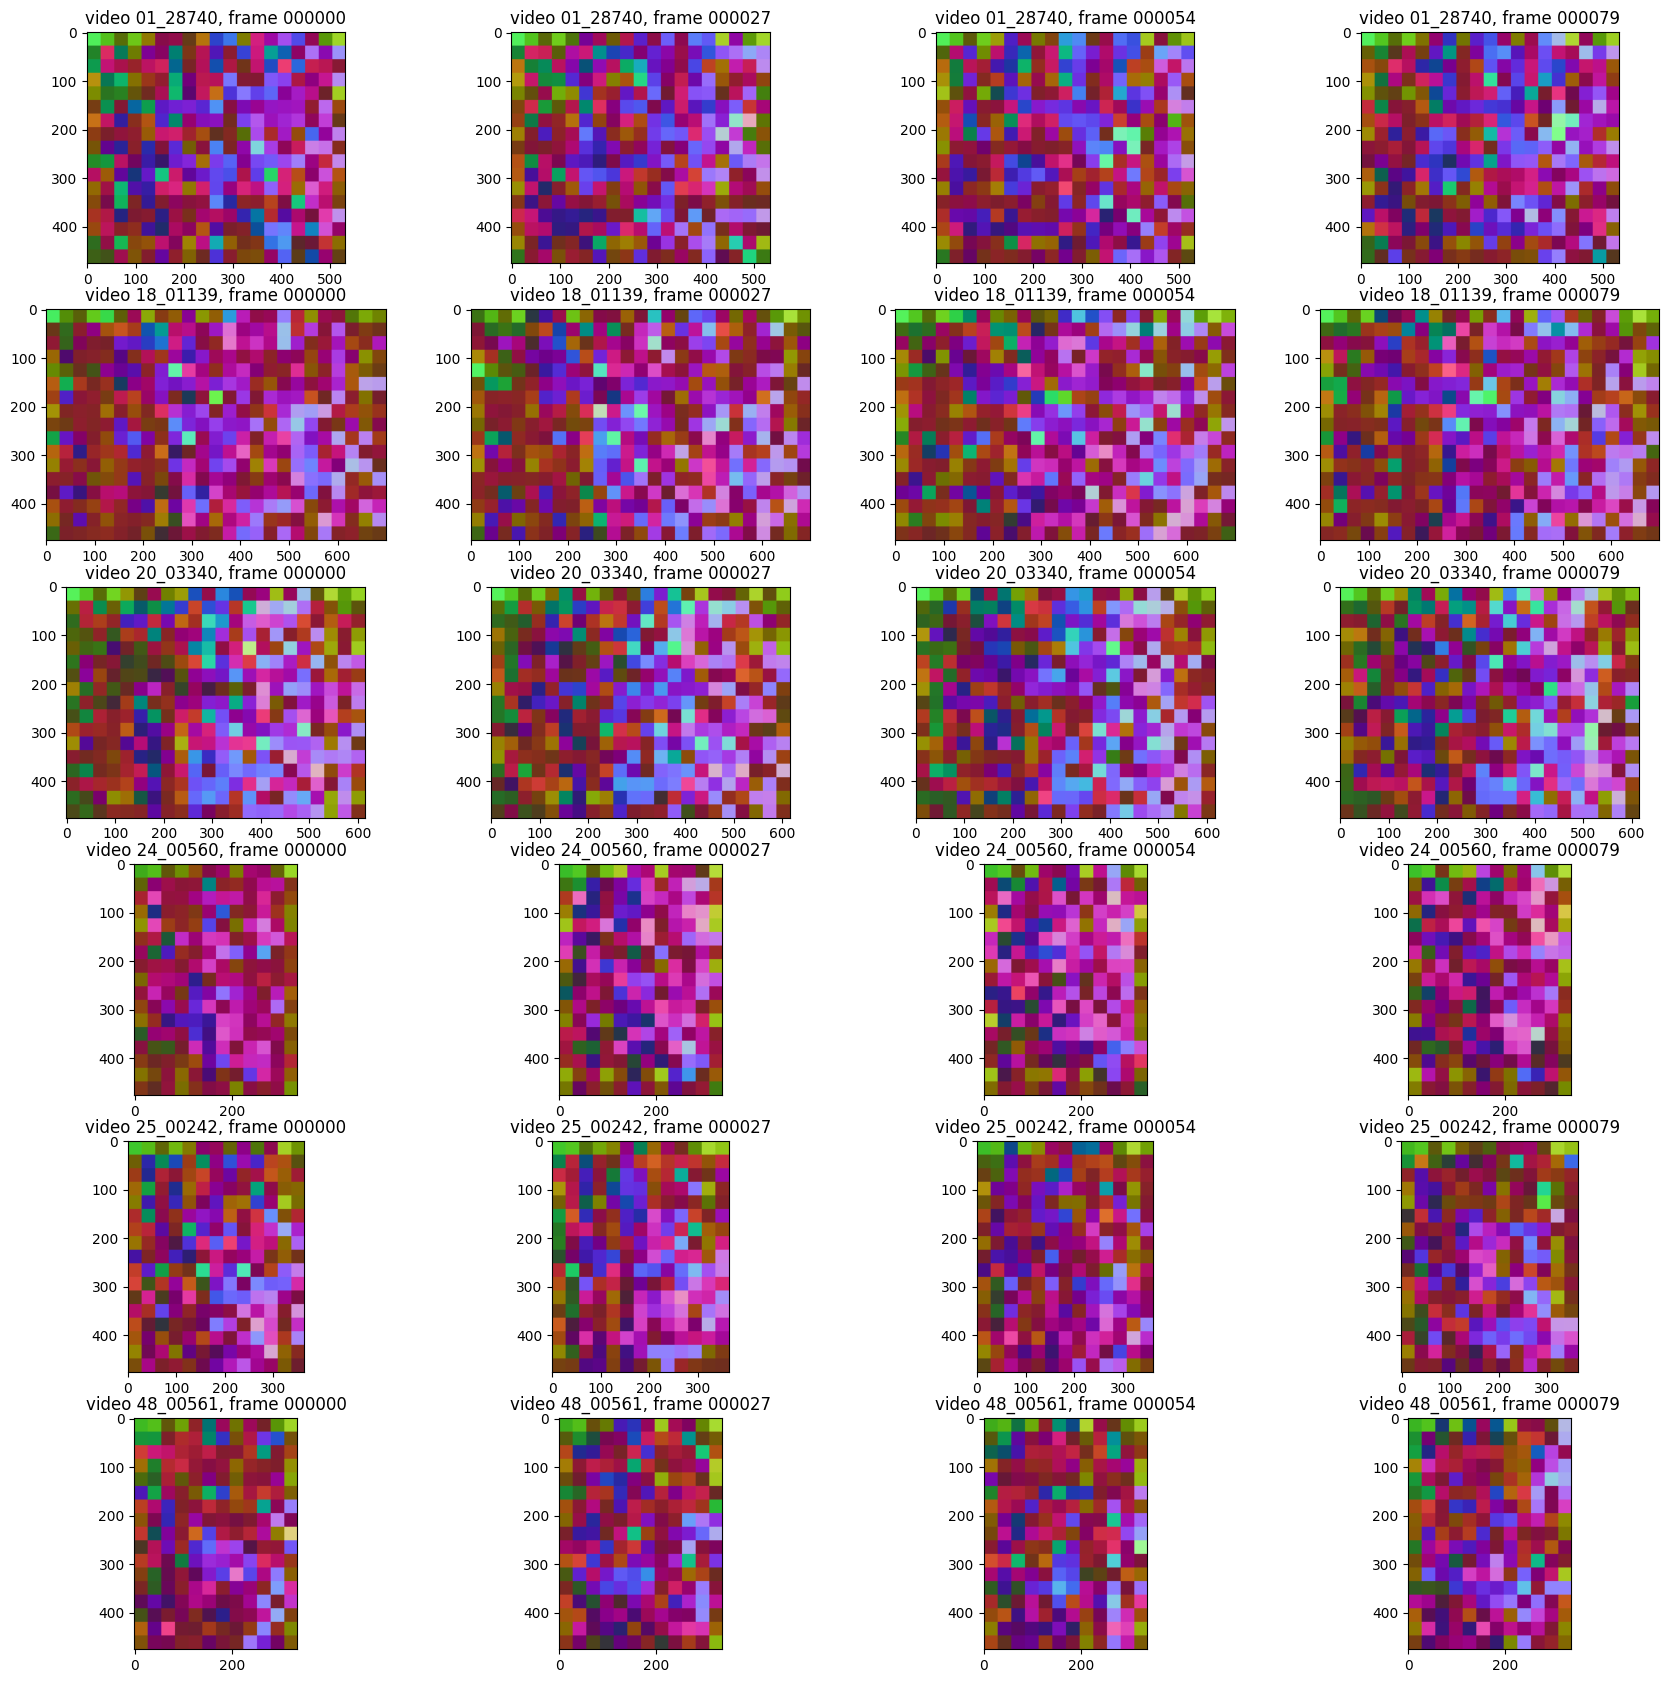

In [50]:
n_videos = 6
display_frames = [0, 27, 54, 79]

video_paths = list(data_path.iterdir())
vid_paths = sorted(random.sample(video_paths, n_videos))
seg_paths = [random.choice(list(vid_path.iterdir())) for vid_path in vid_paths]

fig, axs = plt.subplots(n_videos, len(display_frames), figsize=(21, 21))

for i, seg_path in enumerate(seg_paths):
    vid_id, seg_id = int(str(seg_path)[-8:-6]), int(str(seg_path)[-5:])
    for j, frame_id in enumerate(display_frames):
        frame_path_f =  seg_path / 'qwen_patch_features' / f'frame_{frame_id:06}_f.npy'
        frame_path_s =  seg_path / 'qwen_patch_features' / f'frame_{frame_id:06}_s.npy'

        patch_lf_f = np.load(frame_path_f)
        patch_lf_s = np.load(frame_path_s)[0]

        with torch.no_grad():
            patch_lf_f = ae.encode(torch.as_tensor(patch_lf_f, device='cuda', dtype=torch.float32)).detach().cpu().numpy()
        patch_lf = patch_lf_f[patch_lf_s]
        axs[i, j].imshow(color_transform(patch_lf))
        axs[i, j].set_title(f'video {vid_id:02}_{seg_id:05}, frame {frame_id:06}')
plt.show()